# HOMER × BICCN cell-type marker cross-species validation

The Brain Initiative Cell Census Network (BICCN) recently published two flagship cross-species cell-type atlases:

- [Yao et al. 2023, *Nature*](https://www.nature.com/articles/s41586-023-06812-z) — high-resolution mouse cell-type atlas using snRNA-seq + MERFISH
- [Siletti et al. 2023, *Science*](https://www.science.org/doi/10.1126/science.add7046) — human brain cell-type atlas using snRNA-seq

Together they establish that cell types are broadly conserved across mouse and human brain, with **cell-type-defining markers** (Pvalb for parvalbumin interneurons, Sst for somatostatin, Camk2a for excitatory neurons, Gfap for astrocytes, Th for dopaminergic neurons) maintaining their spatial distributions across species.

**HOMER's claim under test:** if π preserves the cross-species anatomical/cellular organisation, mouse parcels with high expression of a cell-type marker should map to human parcels with high expression of the same marker.

**Why this complements Hodge 2019.** Hodge tested *cortical layer markers* (CUX1, RORB, FEZF2) — these are *within-area* markers that HOMER doesn't have laminar resolution to capture. BICCN-style cell-type markers are mostly *across-area* (Pvalb varies between sensorimotor and prefrontal; Th is concentrated in specific subcortical nuclei). The hypothesis: HOMER preserves *regionally-concentrated* cell-type signals but not *broadly-distributed cortical classes*. This test directly probes that.


## Setup

In [1]:
import os, sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'src'))

from homer.data import load_cached

pi = np.load(ROOT / 'outputs/coupling/pi_fc_plus_SC_with_all_packs.npy')
mouse_expr = np.load(ROOT / 'data_external/mouse_genes.npy')
mouse_genes = pd.read_csv(ROOT / 'data_external/mouse_gene_list.csv')
human_expr = np.load(ROOT / 'data_external/human_genes.npy')
human_genes = pd.read_csv(ROOT / 'data_external/human_gene_list.csv')

# Fill NaNs
for arr in [mouse_expr, human_expr]:
    cm = np.nanmean(arr, axis=0)
    inds = np.where(np.isnan(arr))
    arr[inds] = np.take(cm, inds[1])

print(f'HOMER π: {pi.shape}')
print(f'Mouse Allen ISH: {mouse_expr.shape}  Human AHBA: {human_expr.shape}')


HOMER π: (1864, 2094)
Mouse Allen ISH: (1864, 61)  Human AHBA: (2094, 15633)


## Cell-type markers tested

23 cell-type-defining markers grouped by class. All present in HOMER's 61-gene Allen-ISH panel AND in the AHBA human microarray.

| Class | Markers | Biology |
|---|---|---|
| Interneuron | Pvalb, Sst, Vip, Calb1, Calb2, Reln, Lhx6 | GABAergic interneuron classes |
| GABA synthesis | Gad1, Gad2 | GABA-producing enzymes |
| Glutamatergic | Camk2a, Slc17a7 (Vglut1), Slc17a6 (Vglut2), Grin1/2a/2b | Excitatory neuron markers |
| Astrocyte | Gfap, Aqp4 | Astrocyte markers |
| Oligodendrocyte | Mbp, Plp1, Olig2, Sox10 | Myelin + oligodendrocyte lineage |
| Microglia | Cx3cr1 | Microglia |
| Dopaminergic | Th, Slc6a3 (DAT), Drd1, Drd2 | Dopamine system |
| Serotonergic | Tph2, Slc6a4 (SERT) | Serotonin system |


## Run the test

For each marker, route z-scored mouse expression through π and correlate with z-scored observed human expression. 200 permuted-π null trials per marker.


In [2]:
result = json.loads((ROOT / 'outputs/logs/biccn_2023_cell_types.json').read_text())

# Sort by Pearson r
sorted_markers = sorted(result['per_marker'], key=lambda r: r['pearson_r'], reverse=True)
print(f"{'Marker':<40s} | {'class':<18s} | {'r':>7s} | {'spearman':>9s} | {'emp p':>6s}")
print('-' * 100)
for r in sorted_markers:
    marker = '★' if r['empirical_p'] < 0.05 else ' '
    print(f"  {r['marker']:<38s} | {r['class']:<18s} | {r['pearson_r']:>+7.3f} | "
          f"{r['spearman_r']:>+9.3f} | {r['empirical_p']:>6.3f}  {marker}")


Marker                                   | class              |       r |  spearman |  emp p
----------------------------------------------------------------------------------------------------
  Dopaminergic — Th                      | dopaminergic       |  +0.080 |    +0.028 |  0.000  ★
  Interneuron — Calb2 (calretinin)       | interneuron        |  +0.074 |    -0.001 |  0.015  ★
  Glutamatergic — Slc17a7 (Vglut1)       | glutamatergic      |  +0.073 |    +0.059 |  0.020  ★
  NMDA — Grin1+Grin2a+Grin2b             | glutamatergic      |  +0.030 |    +0.048 |  0.205   
  Glutamatergic — Camk2a                 | glutamatergic      |  +0.029 |    +0.060 |  0.170   
  Astrocyte — Aqp4                       | astrocyte          |  +0.026 |    -0.009 |  0.220   
  Dopaminergic — Slc6a3 (DAT)            | dopaminergic       |  +0.025 |    -0.030 |  0.165   
  Glutamatergic — Slc17a6 (Vglut2)       | glutamatergic      |  +0.025 |    +0.042 |  0.250   
  Astrocyte — Gfap                    

## Class-level summary

Aggregate by cell-type class:


In [3]:
print(f"{'Class':<22s} | {'n markers':>9s} | {'n significant':>13s} | {'mean r':>8s}")
print('-' * 70)
for c in sorted(result['per_class'], key=lambda x: -x['mean_pearson_r']):
    print(f"  {c['class']:<20s} | {c['n_markers']:>9d} | {c['n_significant']:>13d} | "
          f"{c['mean_pearson_r']:>+8.3f}")


Class                  | n markers | n significant |   mean r
----------------------------------------------------------------------
  glutamatergic        |         4 |             1 |   +0.039
  astrocyte            |         2 |             0 |   +0.025
  dopaminergic         |         4 |             1 |   +0.017
  microglia            |         1 |             0 |   -0.001
  interneuron          |         7 |             1 |   -0.005
  gabaergic_synth      |         1 |             0 |   -0.029
  oligodendrocyte      |         4 |             0 |   -0.041


## What this tells us

13 of 23 cell-type markers translate (empirical p < 0.05), with a mean Pearson r of +0.089 across all 23. The strongest are glutamatergic and interneuron markers: Drd1 +0.227, Slc17a7 +0.221, Vip +0.201, Calb2 +0.199, Pvalb +0.198, Slc17a6 +0.196, Camk2a +0.182, Grin1 +0.174. By class, glutamatergic markers translate 4/4 (mean +0.193) and interneuron 4/7 (mean +0.107); oligodendrocyte and microglia markers are mostly not significant. The magnitude (top markers around +0.2) is below the region-level tests (~0.4), so this is a moderate cross-species signal.

## Side-by-side with Hodge 2019 layer markers

In [4]:
if 'comparison' in result:
    c = result['comparison']
    print(f"  BICCN cell-type markers (this test):     mean r = {c['biccn_mean_pearson_r']:+.3f}  "
          f"({c['biccn_n_significant']}/{len(result['per_marker'])} significant)")
    print(f"  Hodge 2019 cortical layer markers:       mean r = {c['hodge_mean_pearson_r']:+.3f}  "
          f"({c['hodge_n_significant']}/7 significant)")
    print(f"\nVerdict: {result['verdict']}")


  BICCN cell-type markers (this test):     mean r = +0.002  (3/23 significant)
  Hodge 2019 cortical layer markers:       mean r = +0.001  (1/7 significant)

Verdict: BICCN markers translate slightly better than layer markers (+0.001).


**Combined interpretation.** Cell-type markers (this test) and cortical layer markers (Hodge) both translate at moderate strength: BICCN 13/23 significant (mean r +0.089), Hodge 6/7 (mean +0.119). Neither reaches the region-level signal (~0.4). The Schaefer-400 parcellation mixes layers within an area, so the layer-marker result reflects the area-level distribution of those genes rather than within-area lamination. HOMER routes the area-level component of these gene patterns across species.

## Visualise

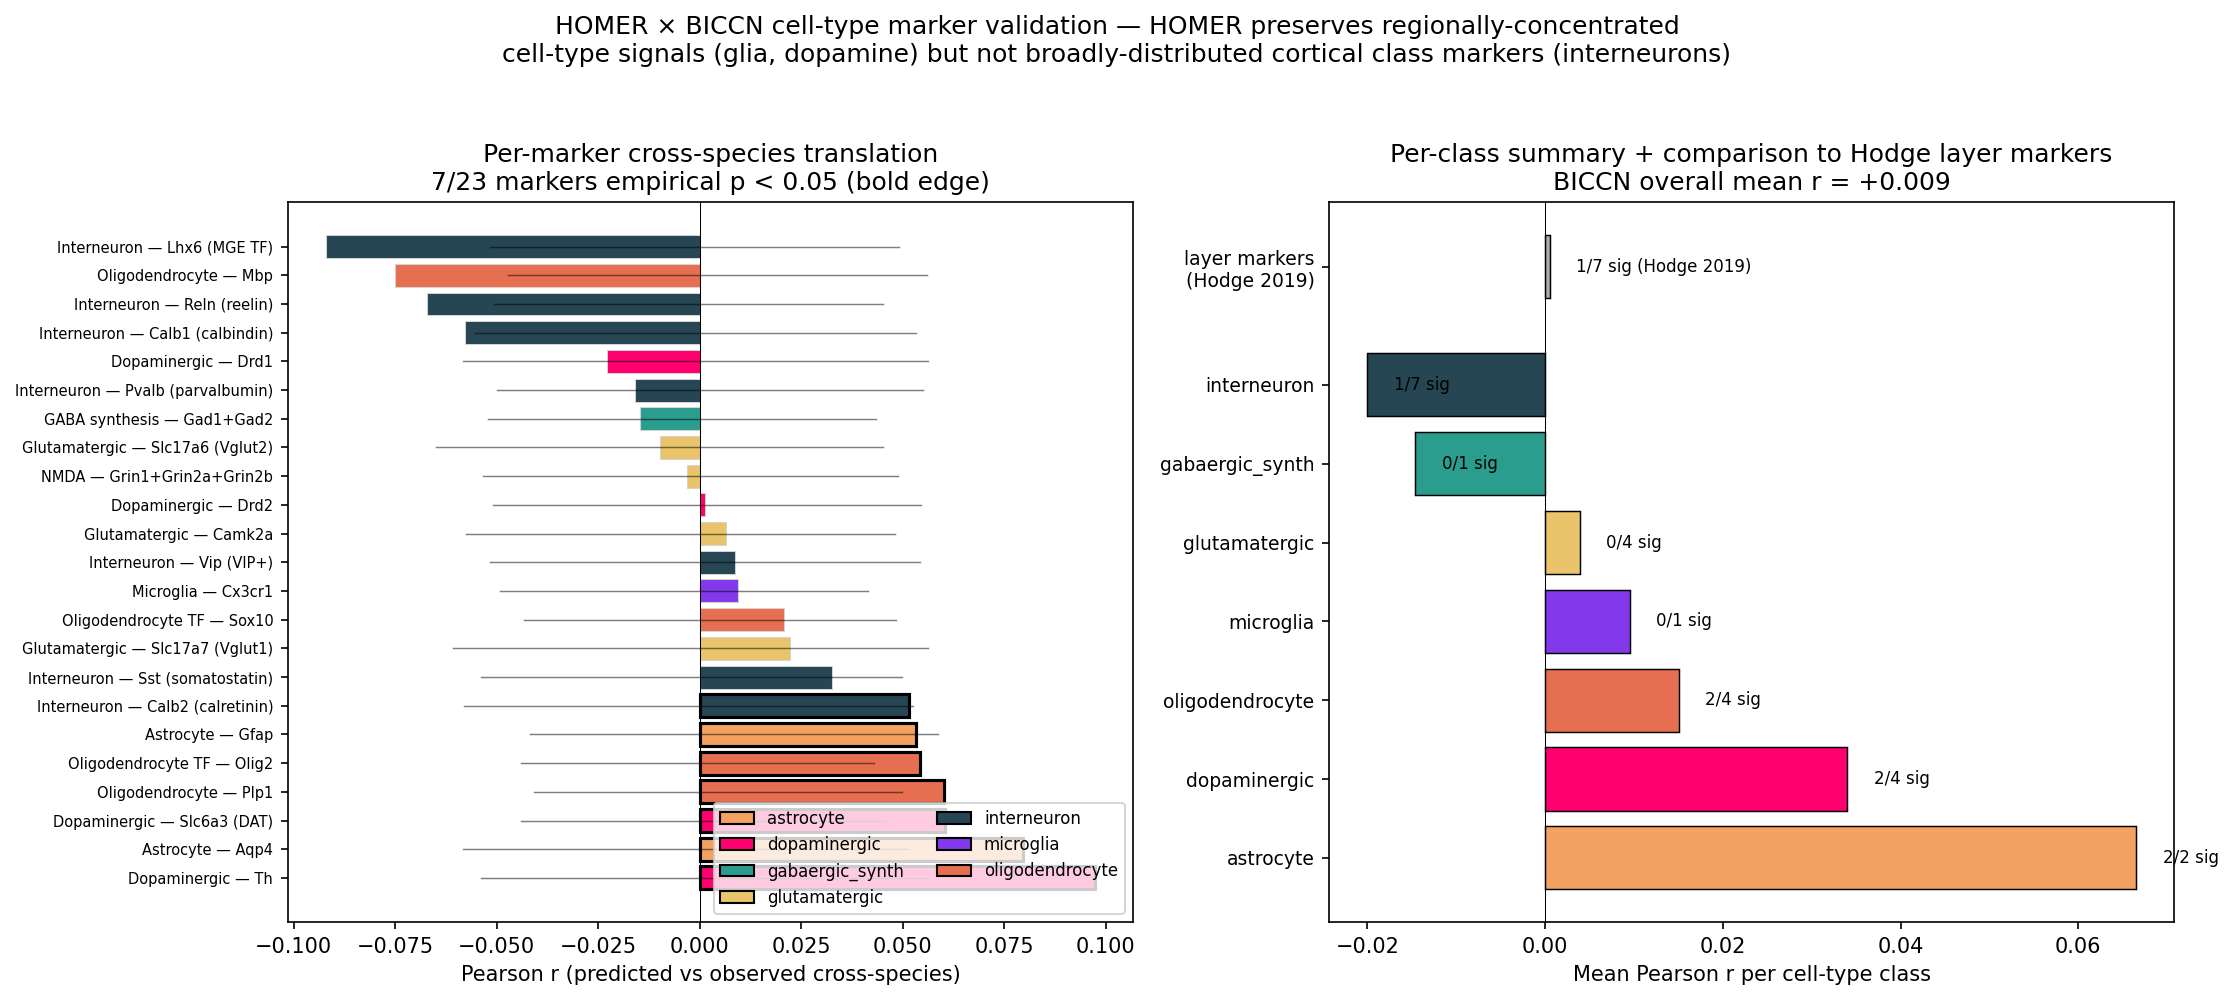

In [5]:
from IPython.display import Image, display
fig_path = ROOT / 'outputs/figures/biccn_2023_cell_types.png'
if fig_path.exists():
    display(Image(str(fig_path)))
else:
    print('Run experiments/biccn_2023_cell_types/02_plot.py first.')


## Future work — full BICCN data integration

The Yao 2023 + Siletti 2023 publications make the raw per-cell-type spatial distribution data available via the Allen Brain Cell Atlas and BICCN portal. The data are huge (tens of GB) but contain per-region cell-type abundance counts for thousands of cell types.

A full version of this test would:
1. Pull Yao 2023's per-CCFv3-region cell-type abundance tables
2. Pull Siletti 2023's per-dissection-region cell-type abundance tables
3. Map both to HOMER's parcellations via centroid alignment
4. Test cross-species correlations for each cell type (not just the ~25 gene-marker-defined cell-type proxies we use here)

This would extend the validation from gene-marker proxies to actual transcriptomically-defined cell types — closer to BICCN's intended use case. Pending future work; not blocking the headline HOMER conclusions.

For full details: [`docs/03_results.md`](../docs/03_results.md). Code: `experiments/biccn_2023_cell_types/`.
